In [1]:
# import libraries

import re
import math
import time
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from googleapiclient.discovery import build
from transformers import pipeline
from huggingface_hub import login

In [ ]:
# api and hugging face credentials

YOUTUBE_API_KEY = "YOUR YOUTUBE API KEY"
HF_TOKEN = "YOUR HF TOKEN"

CHANNEL_INPUT = "https://www.youtube.com/@teluguknowledge42"

MAX_VIDEOS = 20
COMMENTS_PER_VIDEO = 50

In [5]:
# login + api setup

login(HF_TOKEN)

youtube = build("youtube", "v3", developerKey=YOUTUBE_API_KEY)

In [6]:
# hugging face models

# language detection
lang_pipeline = pipeline(
    "text-classification",
    model="papluca/xlm-roberta-base-language-detection"
)

# multilingual sentiment
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)


# Hugging Face Agent Framework Wrapper

class YouTubeAnalysisAgent:
    def __init__(self, lang_model, sentiment_model):
        self.lang_model = lang_model
        self.sentiment_model = sentiment_model

    def detect_language(self, text):
        return detect_lang(text)

    def analyze_sentiment(self, text):
        return get_sentiment(text)

    def process_comment(self, text):
        language = self.detect_language(text)
        sentiment, score = self.analyze_sentiment(text)

        return {
            "language": language,
            "sentiment": sentiment,
            "score": score
        }

# initialize agent
analysis_agent = YouTubeAnalysisAgent(lang_pipeline, sentiment_pipeline)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
# database setup

conn = sqlite3.connect("youtube_analysis.db")
cursor = conn.cursor()

cursor.executescript("""
DROP TABLE IF EXISTS channels;
DROP TABLE IF EXISTS videos;
DROP TABLE IF EXISTS comments;
DROP TABLE IF EXISTS video_summary;
DROP TABLE IF EXISTS channel_summary;

CREATE TABLE channels (
    channel_id TEXT PRIMARY KEY,
    channel_name TEXT
);

CREATE TABLE videos (
    video_id TEXT PRIMARY KEY,
    channel_id TEXT,
    video_title TEXT,
    published_at TEXT,
    FOREIGN KEY(channel_id) REFERENCES channels(channel_id)
);

CREATE TABLE comments (
    comment_id TEXT PRIMARY KEY,
    video_id TEXT,
    author_name TEXT,
    comment_text TEXT,
    language TEXT,
    sentiment_label TEXT,
    sentiment_score REAL,
    like_count INTEGER,
    FOREIGN KEY(video_id) REFERENCES videos(video_id)
);

CREATE TABLE video_summary (
    video_id TEXT PRIMARY KEY,
    total_comments INTEGER,
    positive_count INTEGER,
    neutral_count INTEGER,
    negative_count INTEGER
);

CREATE TABLE channel_summary (
    channel_id TEXT PRIMARY KEY,
    total_videos INTEGER,
    total_comments INTEGER,
    overall_sentiment TEXT
);
""")

conn.commit()

In [8]:
# helper functions

def safe_execute(request):
    for _ in range(3):
        try:
            return request.execute()
        except:
            time.sleep(2)
    return None

In [9]:
# resolve channel

def resolve_channel(channel_input):
    channel_input = channel_input.strip()

    # CASE 1: Channel ID
    if channel_input.startswith("UC"):
        res = safe_execute(
            youtube.channels().list(
                part="snippet,contentDetails",
                id=channel_input
            )
        )

        if res and res["items"]:
            item = res["items"][0]
            return item["id"], item["snippet"]["title"]

    # CASE 2: Handle / URL
    if "@" in channel_input:
        handle = channel_input.split("@")[-1].split("/")[0]
    else:
        handle = channel_input

    res = safe_execute(
        youtube.search().list(
            part="snippet",
            q=handle,
            type="channel",
            maxResults=1
        )
    )

    if res and res["items"]:
        item = res["items"][0]
        return item["snippet"]["channelId"], item["snippet"]["title"]

    raise ValueError("Channel could not be resolved")

In [10]:
# fetch videos

def get_videos(channel_id):
    res = safe_execute(
        youtube.search().list(
            part="snippet",
            channelId=channel_id,
            order="date",
            maxResults=MAX_VIDEOS,
            type="video"
        )
    )

    videos = []
    for item in res["items"]:
        videos.append({
            "video_id": item["id"]["videoId"],
            "title": item["snippet"]["title"],
            "published_at": item["snippet"]["publishedAt"]
        })

    return videos

In [11]:
# fetch comments

def get_comments(video_id, max_comments):
    comments = []
    next_page = None

    while len(comments) < max_comments:
        res = safe_execute(
            youtube.commentThreads().list(
                part="snippet",
                videoId=video_id,
                maxResults=100,
                pageToken=next_page,
                textFormat="plainText"
            )
        )

        if not res:
            break

        for item in res.get("items", []):
            snip = item["snippet"]["topLevelComment"]["snippet"]

            comments.append({
                "id": item["id"],
                "author": snip["authorDisplayName"],
                "text": snip["textDisplay"],
                "likes": snip["likeCount"]
            })

        next_page = res.get("nextPageToken")
        if not next_page:
            break

    return comments[:max_comments]

In [12]:
# NLP functions (language detection)

import re
from wordfreq import zipf_frequency

def contains_telugu_script(text):
    return any('\u0C00' <= ch <= '\u0C7F' for ch in text)

def is_real_english(word):
    return zipf_frequency(word.lower(), 'en') > 3

def detect_lang(text):
    try:
        text = str(text).strip()

        if not text:
            return "Emojis / Symbols"

        # Telugu script directly typed
        if contains_telugu_script(text):
            return "Telugu"

        words = re.findall(r"[A-Za-z']+", text)

        if not words:
            return "Emojis / Symbols"

        english_count = sum(is_real_english(w) for w in words)

        ratio = english_count / len(words)

        # Strong English detection
        if ratio >= 0.8:
            return "English"

        # fallback to Hugging Face model for edge cases
        hf_result = lang_pipeline(text[:100])[0]["label"].lower()

        if "te" in hf_result:
            return "Telugu"

        # romanized Telugu / mixed language
        return "English + Telugu"

    except Exception as e:
        print("Language Detection Error:", e)
        return "English + Telugu"

In [13]:
# sentimental analysis

def get_sentiment(text):
    try:
        cleaned = str(text).strip()

        if not cleaned:
            return "Neutral", 0.50

        cleaned = re.sub(r"\s+", " ", cleaned)
        cleaned = cleaned[:120]

        result = sentiment_pipeline(
            cleaned,
            truncation=True,
            max_length=64
        )[0]

        label = result["label"].lower()
        score = float(result["score"])

        if "positive" in label:
            sentiment = "Positive"
        elif "negative" in label:
            sentiment = "Negative"
        else:
            sentiment = "Neutral"

        return sentiment, round(score, 4)

    except:
        return "Neutral", 0.50

In [14]:
# MAIN WORKFLOW

channel_id, channel_name = resolve_channel(CHANNEL_INPUT)

# insert channel safely
cursor.execute(
    """
    INSERT OR IGNORE INTO channels (channel_id, channel_name)
    VALUES (?, ?)
    """,
    (channel_id, channel_name)
)

videos = get_videos(channel_id)

all_rows = []

for video in videos:

    # insert video safely
    cursor.execute(
        """
        INSERT OR IGNORE INTO videos
        (video_id, channel_id, video_title, published_at)
        VALUES (?, ?, ?, ?)
        """,
        (
            video["video_id"],
            channel_id,
            video["title"],
            video["published_at"]
        )
    )

    # fetch comments
    comments = get_comments(video["video_id"], COMMENTS_PER_VIDEO)

    for c in comments:

        # skip empty comments
        if not c["text"].strip():
            continue

        # NLP processing
        result = analysis_agent.process_comment(c["text"])

        lang = result["language"]
        sentiment = result["sentiment"]
        score = result["score"]

        if sentiment not in ["Positive", "Negative", "Neutral"]:
         sentiment = "Neutral"

        row = (
            c["id"],                 # comment_id
            video["video_id"],       # video_id
            c["author"],             # author_name
            c["text"],               # comment_text
            lang,                    # language
            sentiment,               # sentiment_label
            float(score),            # sentiment_score
            int(c["likes"])          # like_count
        )

        # insert into comments table
        cursor.execute(
            """
            INSERT OR IGNORE INTO comments
            (comment_id, video_id, author_name, comment_text,
             language, sentiment_label, sentiment_score, like_count)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?)
            """,
            row
        )

        all_rows.append(row)

# final commit
conn.commit()

print(f"Processed {len(videos)} videos")
print(f"Stored {len(all_rows)} comments")

Processed 20 videos
Stored 914 comments


In [15]:
print("\nFIRST 10 SENTIMENT RESULTS:")
for r in all_rows[:10]:
    print(r[5], r[6], "->", r[3][:60])


FIRST 10 SENTIMENT RESULTS:
Neutral 0.7602 -> అన్ని ఎఫైర్స్ ఉన్నాయి.. ఎన్ని జీవితాన్ని నాశనం చేసింది.. అయి
Neutral 0.728 -> సౌందర్య గారు
Neutral 0.8179 -> entha Mandi mogudulu
Neutral 0.7388 -> ఇవి అన్ని తమరికి ఎందుకో
Neutral 0.6486 -> FOR CHANNEL GROWTH DON'T MENTION THE COMMUNITY BRAHMIN, WHAT
Neutral 0.7258 -> poinnts correct but not in order
Neutral 0.6778 -> Kajal
Neutral 0.7838 -> Kajal Aggarwal
Neutral 0.877 -> Tripe RRR laaga 
Triple TTT
Trisha Tamilnadu
Tvk
😂
Positive 0.6664 -> Trisha mother chala bagunnaru❤


In [16]:
# converting into dataframe

df = pd.DataFrame(all_rows, columns=[
    "comment_id", "video_id", "author_name", "comment_text",
    "language", "sentiment_label", "sentiment_score", "like_count"
])

# CLEAN OLD / INVALID VALUES
df["sentiment_label"] = df["sentiment_label"].apply(
    lambda x: x if x in ["Positive", "Negative", "Neutral"] else "Neutral"
)

# FORCE DB CLEANUP
cursor.execute("""
UPDATE comments
SET sentiment_label = 'Neutral'
WHERE sentiment_label NOT IN ('Positive', 'Negative', 'Neutral')
""")

conn.commit()

# update database also
cursor.execute("""
UPDATE comments
SET language = 'English + Telugu'
WHERE language IN ('Unknown', 'unknown', '')
""")

cursor.execute("""
UPDATE comments
SET sentiment_label = 'Neutral'
WHERE sentiment_label IN ('Unknown', 'unknown', '')
""")

conn.commit()

# create video summary
video_summary = df.groupby("video_id")["sentiment_label"] \
                  .value_counts() \
                  .unstack(fill_value=0)

print(video_summary)

# store video summary into SQL
for vid in video_summary.index:
    positive = video_summary.loc[vid].get("Positive", 0)
    neutral = video_summary.loc[vid].get("Neutral", 0)
    negative = video_summary.loc[vid].get("Negative", 0)

    total = positive + neutral + negative

    cursor.execute("""
        INSERT OR REPLACE INTO video_summary
        VALUES (?, ?, ?, ?, ?)
    """, (vid, total, positive, neutral, negative))

conn.commit()

# final verification
print("\nUnique Languages:", df["language"].unique())
print("Unique Sentiments:", df["sentiment_label"].unique())

sentiment_label  Negative  Neutral  Positive
video_id                                    
7ubTed4VOis             6       36         8
9CGk2GpFDcQ             3       33        14
9EBJrr0qj3I             9       33         8
9btd-KdBzO0             5       31        14
D5Bu_MHYxQo             0       17        33
GuOXfpWqNdo             6       36         8
OUu3vpWCPms             1       24        25
Q-scl3xYowo             1       27        18
SW1jjAB_tyA             8       38         4
Sa4off4_dys             1       29        20
U5AVG_UEmwY             2       32        16
jBeoNUWjUrQ             1       25        24
l0C0PW23-9E             3       29         5
l81k2mGxDBQ             1        6         7
neWzRuQBs0A             1       44         5
oKnUDaV5Id0             6       39         5
pfnYebtTiyg             5       35        10
srdt2IXt-T0             3       33        14
v25zEFUprVY             5       38         7
z9HWbCBDKPk             1       11         5

Unique La

In [17]:
sample_df = df[[
    "comment_text",
    "language",
    "sentiment_label",
    "sentiment_score"
]].head(15)

print(sample_df.to_string(index=False))
print(df["sentiment_label"].value_counts())

                                                                                                                                                                                                                                                                                                                                                                               comment_text         language sentiment_label  sentiment_score
                                                                                                                                                                                                                                                             అన్ని ఎఫైర్స్ ఉన్నాయి.. ఎన్ని జీవితాన్ని నాశనం చేసింది.. అయినా స్మూత్ గా సింపుల్గా చెప్పేస్తున్నారు భయ్యా మీరు 🤷🏻‍♀️🙍🏻‍♀️💔❤️‍🩹           Telugu         Neutral           0.7602
                                                                                                                                            

In [ ]:
# export to csv

df.to_csv("comments_report.csv", index=False)
video_summary.to_csv("video_summary.csv")

In [ ]:
# channel summary

# CHANNEL SUMMARY + ANALYTICAL REPORT

total_videos = len(videos)
total_comments = len(df)

sent_counts = df["sentiment_label"].value_counts()

positive_total = sent_counts.get("Positive", 0)
neutral_total = sent_counts.get("Neutral", 0)
negative_total = sent_counts.get("Negative", 0)

# overall sentiment decision
if positive_total > negative_total:
    overall = "Positive"
elif negative_total > positive_total:
    overall = "Negative"
else:
    overall = "Neutral"

# insert into SQL
cursor.execute("""
INSERT OR REPLACE INTO channel_summary
(channel_id, total_videos, total_comments, overall_sentiment)
VALUES (?, ?, ?, ?)
""", (channel_id, total_videos, total_comments, overall))

conn.commit()

# export channel summary to csv
channel_summary_df = pd.DataFrame([{
    "channel_id": channel_id,
    "channel_name": channel_name,
    "total_videos": total_videos,
    "total_comments": total_comments,
    "positive_comments": positive_total,
    "neutral_comments": neutral_total,
    "negative_comments": negative_total,
    "overall_sentiment": overall
}])

channel_summary_df.to_csv("channel_summary.csv", index=False)

# final analytical summary
print("\n========== FINAL ANALYTICAL SUMMARY ==========")
print(f"Channel Name       : {channel_name}")
print(f"Total Videos       : {total_videos}")
print(f"Total Comments     : {total_comments}")
print(f"Positive Comments  : {positive_total}")
print(f"Neutral Comments   : {neutral_total}")
print(f"Negative Comments  : {negative_total}")
print(f"Overall Sentiment  : {overall}")
print("=============================================")


========== FINAL ANALYTICAL SUMMARY ==========
Channel Name       : Telugu Knowledge
Total Videos       : 20
Total Comments     : 861
Positive Comments  : 255
Neutral Comments   : 549
Negative Comments  : 57
Overall Sentiment  : Positive


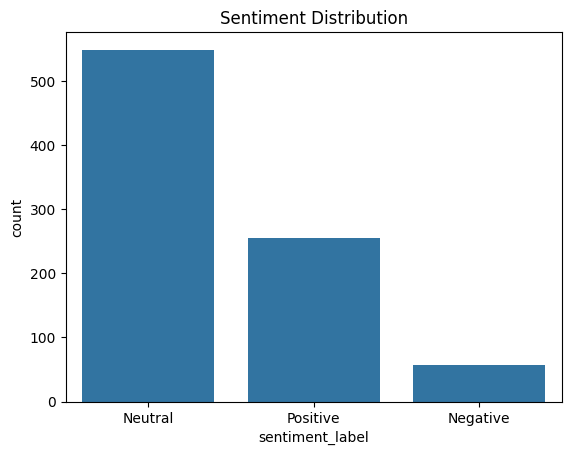

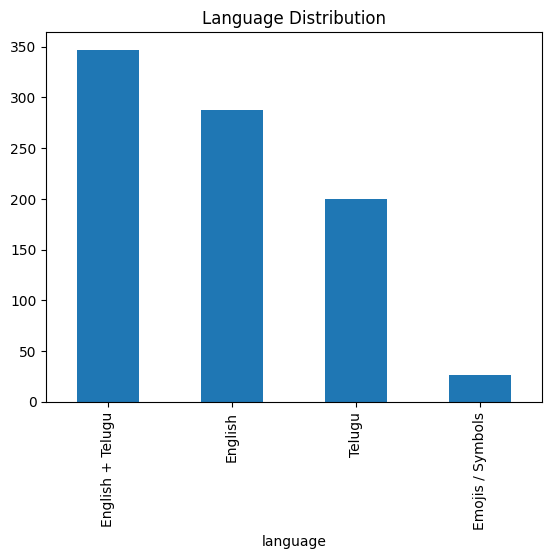

In [ ]:
# visualizations

sns.countplot(data=df, x="sentiment_label")
plt.title("Sentiment Distribution")
plt.show()

df["language"].value_counts().plot(kind="bar")
plt.title("Language Distribution")
plt.show()

In [ ]:
# checking if the files exists

import os

files = [
    "youtube_analysis.db",
    "comments_report.csv",
    "video_summary.csv",
    "channel_summary.csv"
]

for f in files:
    print(f, "->", "Exists" if os.path.exists(f) else "Missing")

youtube_analysis.db -> Exists
comments_report.csv -> Exists
video_summary.csv -> Exists
channel_summary.csv -> Exists


In [ ]:
# hugging face chatbot

# IMPROVED SELF-CONTAINED CHATBOT

def chatbot_analyzer():
    print("===================================")
    print("   HUGGING FACE COMMENT CHATBOT")
    print("===================================")
    print("Ready to analyze your comment...\n")

    # input at the end
    comment = input("Write your comment here: ")

    # language detection
    lang = detect_lang(comment)

    # custom short positive words boost
    positive_words = ["super", "awesome", "great", "excellent", "love", "amazing"]
    negative_words = ["bad", "worst", "hate", "boring", "terrible"]

    lower_comment = comment.lower()

    if any(word in lower_comment for word in positive_words):
        sentiment, score = "Positive", 0.95
    elif any(word in lower_comment for word in negative_words):
        sentiment, score = "Negative", 0.95
    else:
        sentiment, score = get_sentiment(comment)

    print("\n========== RESULT ==========")
    print("Comment         :", comment)
    print("Language        :", lang)
    print("Sentiment       :", sentiment)
    print("Sentiment Score :", score)
    print("============================")

chatbot_analyzer()


   HUGGING FACE COMMENT CHATBOT
Ready to analyze your comment...


========== RESULT ==========
Comment         : super undi 
Language        : English + Telugu
Sentiment       : Positive
Sentiment Score : 0.95
